In [37]:
print("1411262011_謝晨佑")

1411262011_謝晨佑


Cloning into 'xiaoyo8520.github.io'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 48 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 1.21 MiB | 8.24 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/xiaoyo8520.github.io
建立資料夾: /content/data
檔案不存在，開始下載...
Downloading...
From (original): https://drive.google.com/uc?id=1G4Kw8BTruPwOHoQOY-QTZndm2HPfRxr5
From (redirected): https://drive.google.com/uc?id=1G4Kw8BTruPwOHoQOY-QTZndm2HPfRxr5&confirm=t&uuid=244e9af6-5569-4ef6-a42c-d2f82fb64648
To: /content/data/CWRU_48K.npz
100% 52.8M/52.8M [00:00<00:00, 180MB/s]
類別對應表：
索引 0 -> 類別名稱: B (總共 2481 筆)
索引 1 -> 類別名稱: IR (總共 2394 筆)
索引 2 -> 類別名稱: Normal (總共 824 筆)
索引 3 -> 類別名稱: OR (總共 5553 筆)


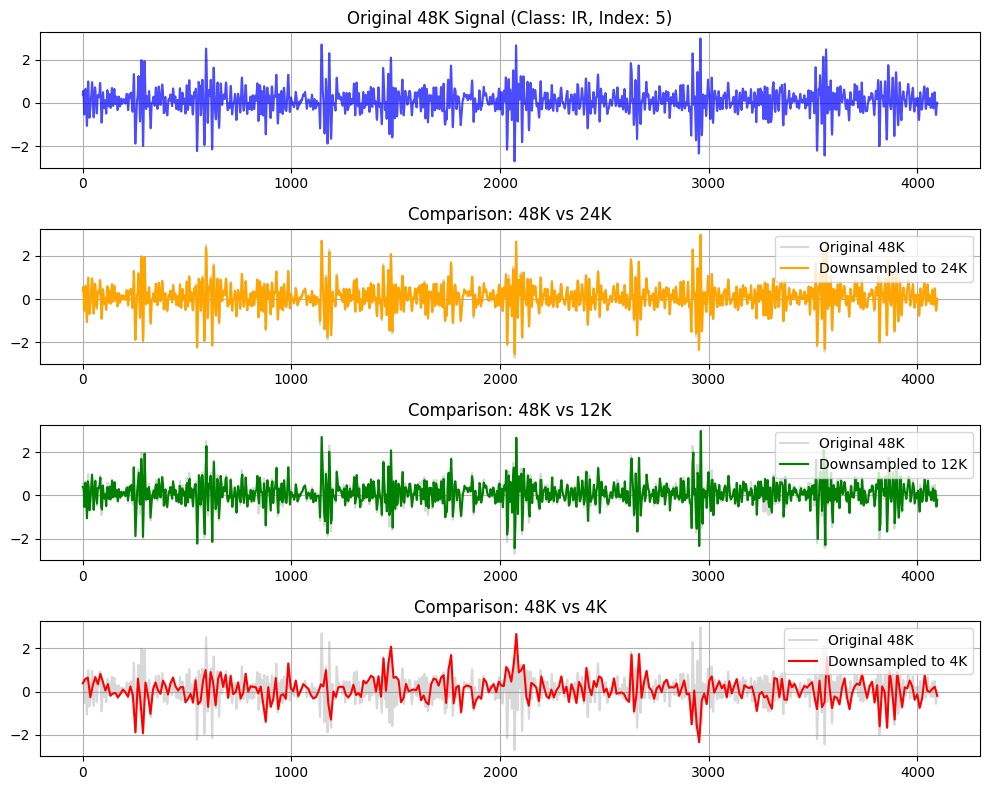

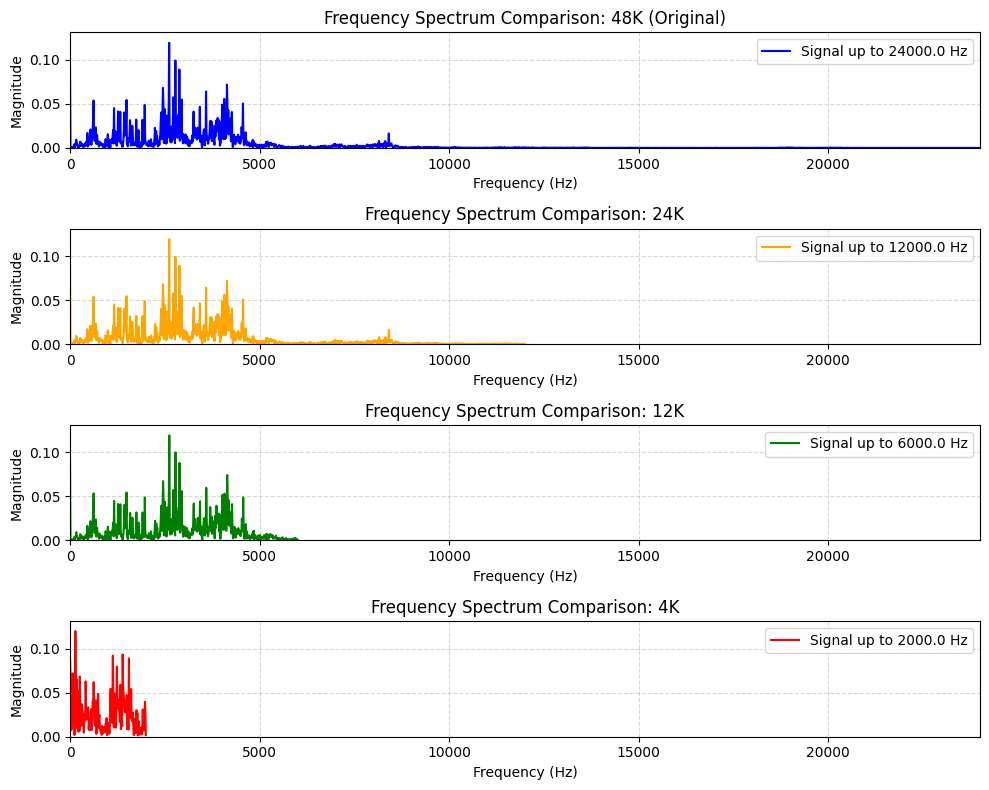

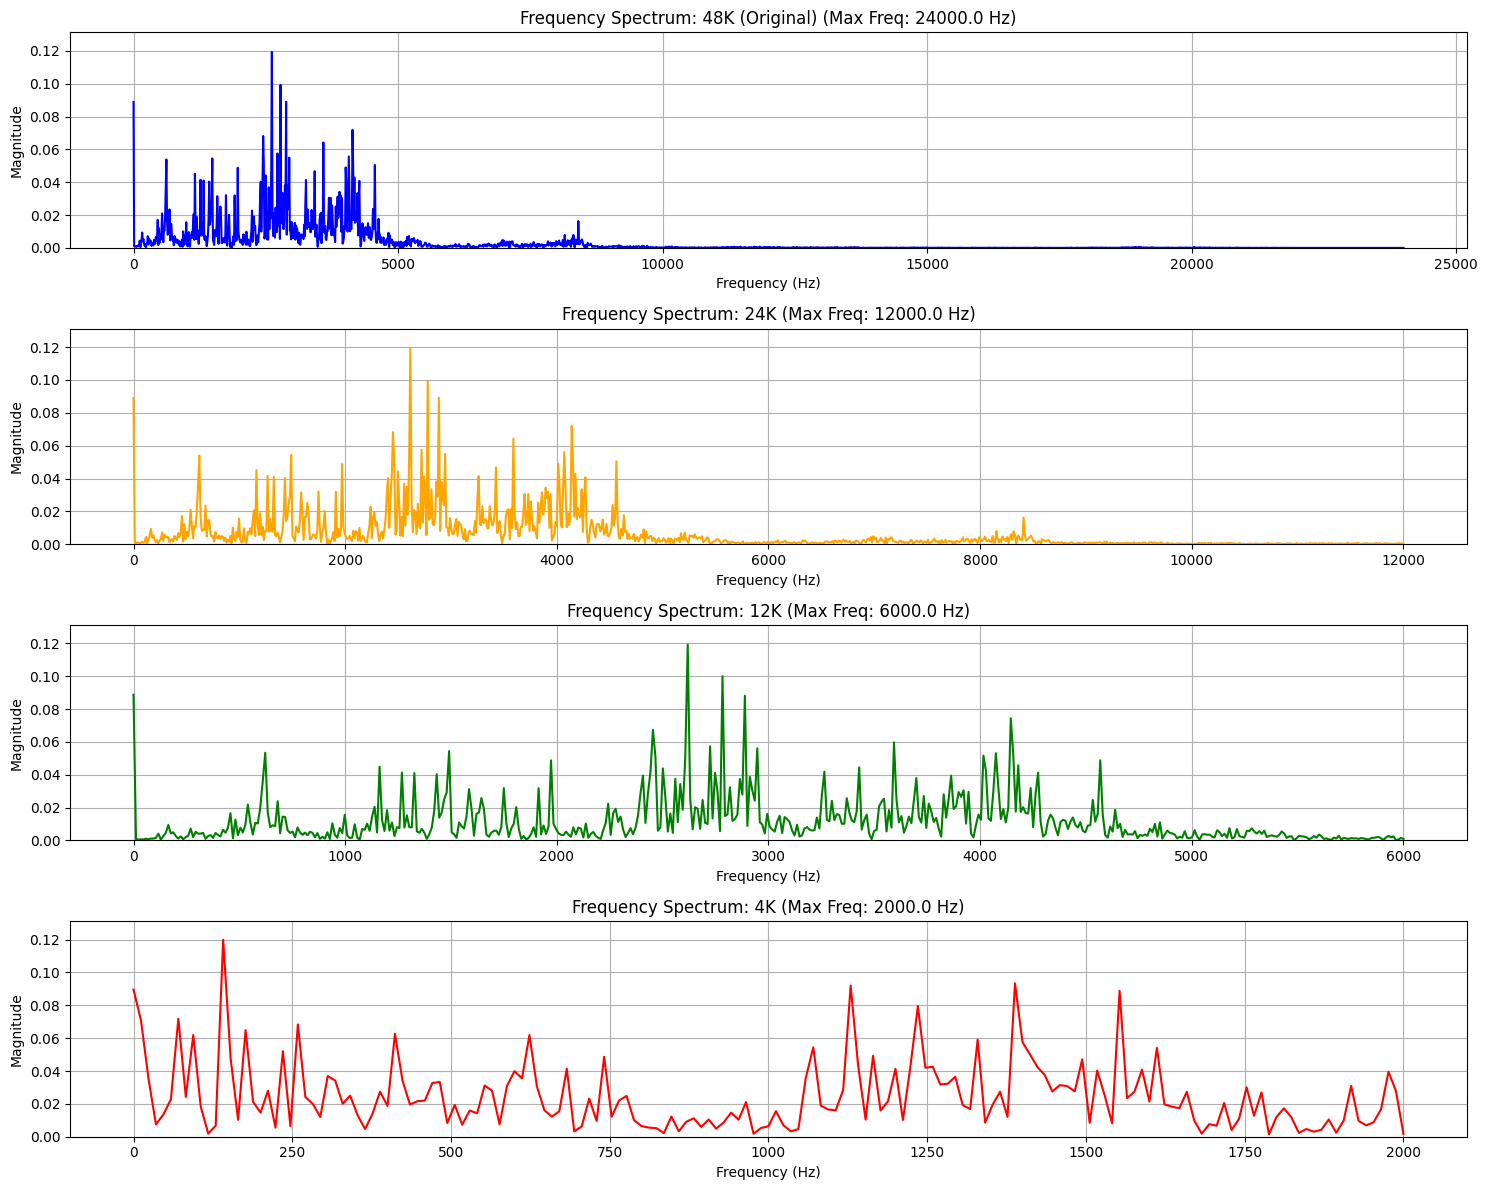

開始處理數據...
類別 B: 挑選 500 筆
類別 IR: 挑選 500 筆
類別 Normal: 挑選 500 筆
類別 OR: 挑選 500 筆

✅ 數據已儲存至: /content/data//CWRU_preprocessed_data3.npz
RAW 形狀: (2000, 4096)
FFT 形狀: (2000, 2048)


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models ,optimizers
from sklearn.model_selection import train_test_split
from pathlib import Path
from collections import defaultdict
from google.colab import drive

# 載入雲端硬碟

#不掛載google drive，需要下一行註解
drive.mount('/content/drive')

# ==========================================
# 步驟：讀取數據
# ==========================================
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/data/CWRU_preprocessed_data3.npz"

### 先將data..ipynb準備好在同個目錄下
### 用github存取，需先在CWRU_dataProPocessing.ipynb將資料存取與建立在"content/data"
##輸入CWRU 專案 ipyhb 路徑
#github_username = ""
#repo = ""
#!git clone https://github.com/{github_username}/{repo}.git
#%cd {repo}
#%run CWRU_dataProPocessing.ipynb
#DATA_PATH = "/content/data/CWRU_preprocessed_data3.npz"

### 使用github

data = np.load(DATA_PATH, allow_pickle=True)

In [38]:
# 試著更改架構、優化器、LOSS... 降低模型大小，並試著讓train_acc與Val_acc最大化

from tensorflow.keras.optimizers import Adam , AdamW

def se_block(inputs, ratio=4):
    channels = inputs.shape[-1]
    x = layers.GlobalAveragePooling1D()(inputs)
    x = layers.Dense(channels // ratio, activation='relu')(x)
    x = layers.Dense(channels, activation='sigmoid')(x)
    x = layers.Reshape((1, channels))(x)

    return layers.Multiply()([inputs, x])
def build_1d_cnn_mini(input_shape, num_classes, total_steps=15000):
    inputs = layers.Input(shape=input_shape)
    x = layers.GaussianNoise(0.01)(inputs)

    x = layers.SeparableConv1D(6, 15, padding='same',depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = se_block(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SeparableConv1D(12, 7, padding='same',depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = se_block(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.SeparableConv1D(24, 3, padding='same', depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = se_block(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(24, activation='swish')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    lr_schedule = optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-4,
        decay_steps=total_steps,
        warmup_target=8e-4,
        warmup_steps=int(total_steps * 0.1),
        alpha=0.0001
    )
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4, clipnorm=0.5,global_clipnorm=None),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_1d_cnn_vn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GaussianNoise(0.01),
        layers.SeparableConv1D(8,3,padding='same',activation='swish'),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.1),
        layers.MaxPooling1D(2),

        layers.SeparableConv1D(16,3,padding='same',activation='swish'),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.1),
        layers.MaxPooling1D(2),

        layers.SeparableConv1D(32,3,padding='same',activation='swish'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation='swish'),
        layers.Dropout(0.2),
        layers.Dense(num_classes,activation='softmax')
    ])
    model.compile(
        optimizer=AdamW(learning_rate=1e-3#,clipnorm=1.0,weight_decay=1e-4
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_1d_cnn_v2(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv1D(8, 3, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(16, 3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(32, 3, activation='relu'),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate= 1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_1d_cnn(input_shape, num_classes):
    model = models.Sequential([
        # 第一層卷積：捕捉局部震動特徵
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),

        # 第二層卷積：捕捉更深層的特徵
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),

        # 展平並進入全連接層
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2), # 防止過擬合
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [39]:
import tensorflow.keras.backend as K

def eca_block(inputs, k_size=3):
    channels = inputs.shape[-1]
    x = layers.GlobalAveragePooling1D()(inputs)
    x = layers.Reshape((channels, 1))(x)
    x = layers.Conv1D(1, kernel_size=k_size, padding='same', use_bias=False)(x)
    x = layers.Activation('sigmoid')(x)
    x = layers.Reshape((1, channels))(x)
    return layers.Multiply()([inputs, x])

def spatial_attention(inputs):
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(inputs)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(inputs)

    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    sa = layers.Conv1D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return layers.Multiply()([inputs, sa])

def simam_module(inputs, e_lambda=1e-4):
    def simam_fn(x):
        n = tf.cast(tf.shape(x)[1] - 1, tf.float32)
        mu = tf.reduce_mean(x, axis=1, keepdims=True)
        d = tf.square(x - mu)
        v = tf.reduce_sum(d, axis=1, keepdims=True) / n
        e_inv = d / (4 * (v + e_lambda)) + 0.5
        return x * tf.nn.sigmoid(e_inv)
    return layers.Lambda(simam_fn)(inputs)

def build_1d_cnn_plus(input_shape, num_classes , total_steps = 15000):
    inputs = layers.Input(shape=input_shape)
    x = layers.GaussianNoise(0.01)(inputs)

    x = layers.SeparableConv1D(6, 31, padding='same', activation='swish',depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)

    shortcut = layers.Conv1D(12, 1, padding='same')(x)

    x = layers.SeparableConv1D(12, 7, padding='same', activation='swish',depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)

    x = layers.BatchNormalization()(x)
    x = eca_block(x)
    x = spatial_attention(x)

    x = layers.Add()([shortcut, x])
    x = layers.MaxPooling1D(4)(x)

    x = layers.SeparableConv1D(24, 3, padding='same', activation='swish',depthwise_initializer='he_normal',pointwise_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(24, activation='swish')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    lr_schedule = optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-4,
        decay_steps=total_steps,
        warmup_target=8e-4,
        warmup_steps=int(total_steps * 0.1),
        alpha=0.0001
    )
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4,clipnorm=0.5,global_clipnorm=None),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [40]:
# ==========================================
# 步驟：準備數據
# ==========================================
# --- 選項：選擇要訓練的資料類型 ('raw' 或 'fft') ---
DATA_MODE = 'raw'  # 👈 在這裡切換 'raw' 或 'fft'
# ----------------------------------------------

X = data[DATA_MODE]
y = data['labels']
label_names = data['label_names']

# 1D-CNN 需要輸入維度為 (樣本數, 長度, 通道數)
# 這裡通道數為 1 (單感測器訊號)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 切分訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"目前訓練模式: {DATA_MODE}")
print(f"訓練資料形狀: {X_train.shape}")

# 建立並顯示模型摘要
#model = build_1d_cnn_v2(input_shape=(X.shape[1], 1), num_classes=len(label_names))
model = build_1d_cnn_plus(input_shape=(X.shape[1], 1), num_classes=len(label_names),total_steps = (len(X_train)//32) * 300) #計算步長
model.summary()

目前訓練模式: raw
訓練資料形狀: (1600, 4096, 1)


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 4096, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_11   │ (None, 4096, 1)   │          0 │ input_layer_11[0… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_32 │ (None, 4096, 6)   │         43 │ gaussian_noise_1… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096, 6)   │         24 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_23    │ (None, 1024, 6)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_33 │ (None, 1024, 12)  │        126 │ max_pooling1d_23… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 12)  │         48 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 12)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_24          │ (None, 12, 1)     │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 12, 1)     │          3 │ reshape_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 12, 1)     │          0 │ conv1d_27[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_25          │ (None, 1, 12)     │          0 │ activation_17[0]… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_23         │ (None, 1024, 12)  │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ reshape_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_16 (Lambda)  │ (None, 1024, 1)   │          0 │ multiply_23[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, 1024, 1)   │          0 │ multiply_23[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 1024, 2)   │          0 │ lambda_16[0][0],  │
│ (Concatenate)       │                   │            │ lambda_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 1024, 1)   │         15 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 1024, 12)  │         84 │ max_pooling1d_23… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,487 (5.81 KB)

 Trainable params: 1,403 (5.48 KB)

 Non-trainable params: 84 (336.00 B)

In [41]:
# 開始訓練

history = model.fit(
    X_train, y_train,
    epochs=350, ## 20
    batch_size=32,
    validation_split=0.1
)

# 評估測試集
test_loss, test_acc = model.evaluate(X_test, y_test)


Epoch 1/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 236ms/step - accuracy: 0.2590 - loss: 1.4787 - val_accuracy: 0.2188 - val_loss: 1.4140
Epoch 2/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 0.3021 - loss: 1.3966 - val_accuracy: 0.1312 - val_loss: 1.3862
Epoch 3/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.3771 - loss: 1.2918 - val_accuracy: 0.1937 - val_loss: 1.3524
Epoch 4/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - accuracy: 0.4639 - loss: 1.1914 - val_accuracy: 0.4938 - val_loss: 1.3089
Epoch 5/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.4931 - loss: 1.1241 - val_accuracy: 0.4250 - val_loss: 1.2563
Epoch 6/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.5319 - loss: 1.0564 - val_accuracy: 0.4750 - val_loss: 1.1923
Epoch 7/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step - accuracy: 0.5479 - loss: 1.0189 - val_accuracy: 0.5000 - val_loss: 1.1150
Epoch 8/350
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.5590 - loss: 0.9630 - 

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt


# 評估測試集
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n測試集準確度 ({DATA_MODE}): {test_acc:.4f}")


# --------------------------------------------------------
# 遍歷 history 並計算評分 (TRAIN_ACC + VAL_ACC)
# 請不要更動此部分
##############################
train_acc_history = history.history['accuracy']
val_acc_history = history.history['val_accuracy']
combined_scores = []

print(f"\n{'Epoch':<10}{'Train Acc':<15}{'Val Acc':<15}{'Total Score':<15}")
print("-" * 55)

for i in range(len(train_acc_history)):
    t_acc = train_acc_history[i]
    v_acc = val_acc_history[i]
    score = t_acc + v_acc
    combined_scores.append(score)
    print(f"{i+1:<10}{t_acc:<15.4f}{v_acc:<15.4f}{score:<15.4f}")

# 找出最高評分
max_score = max(combined_scores)
max_score_epoch = combined_scores.index(max_score) + 1

print("-" * 55)
print(f"最高評分總和: {max_score:.4f} (發生於第 {max_score_epoch} 個 Epoch)")
# --------------------------------------------------------

# 繪製訓練曲線與評分曲線
plt.figure(figsize=(12, 5))

# 子圖 1: 準確度
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title(f'Accuracy - {DATA_MODE.upper()}')
plt.grid(True)

# 子圖 2: 評分總和 (Score)
plt.subplot(1, 2, 2)
plt.plot(combined_scores, label='Score (Train+Val Acc)', color='purple', linewidth=2)
plt.axhline(y=max_score, color='r', linestyle='--', label=f'Max Score: {max_score:.4f}')
plt.xlabel('Epoch')
plt.ylabel('Total Score')
plt.legend(loc='lower right')
plt.title(f'Evaluation Score - {DATA_MODE.upper()}')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
## cnn_v2() 加入 BatchNormalization 、GlobalAveragePooling1D ，取消展平 Flatten，Adam改為AdamW
## Total_params 10500，減少400倍， 若連接 16-32-64，減半 變成 8-16-32，Total_params 3400
##Epochs 增加10-15倍
##max( train_acc +v_acc ) = 1.97 - 1.99，,原來是1.8多
##調整 adam、adamW，以及lr、weighty，配合epochs = 250-300間，total_acc在[1.95,1.97]區間

##v2,vn,mini test
## Total_params : 914，acc:1.85-1.86  2700 acc:1.89
##                    2127 acc:1.90  2300 acc:1.96
##                     1700  acc:1.96
##         914 : acc:1.94,多次在 1.89-1.92

## total_acc 浮動大

## plus 1484 ,acc:1.93-1.96
